In [17]:
from lightgbm import LGBMClassifier
import pandas as pd
import numpy as np
from features_bulider import load_and_build,build_crypto_features

In [18]:
def analyze_confidence_thresholds(y_test, y_pred, y_pred_proba, thresholds=[0.50,0.55, 0.60, 0.65, 0.70, 0.75]):
    """
    Evaluates accuracy of predictions above selected confidence thresholds.
    Helps determine where the model has real trading edge.
    """

    test_results = pd.DataFrame({
        'actual': y_test.values,
        'predicted': y_pred,
        'proba_down': y_pred_proba[:, 0],
        'proba_up': y_pred_proba[:, 1]
    })

    # Determine confidence score (highest of the two)
    test_results['confidence'] = test_results[['proba_down', 'proba_up']].max(axis=1)

    print("\n===== HIGH-CONFIDENCE TRADE ANALYSIS =====")
    for threshold in thresholds:
        mask = test_results['confidence'] > threshold
        count = mask.sum()

        if count > 0:
            acc = (test_results.loc[mask, 'actual'] == test_results.loc[mask, 'predicted']).mean()
            print(f"Confidence > {threshold}: {count:4d} trades ({count/len(test_results)*100:5.2f}%) - Accuracy: {acc:.4f}")
        else:
            print(f"Confidence > {threshold}: 0 trades")

    return test_results

In [19]:
# model = LGBMClassifier(
#             max_depth=2,
#             num_leaves=7,
#             min_child_samples=100,
#             n_estimators=150,
#             learning_rate=0.03,
#             reg_alpha=1.5,
#             reg_lambda=1.5,
#             subsample=0.6,
#             colsample_bytree=0.6,
#             class_weight='balanced',
#             random_state=42,
#             verbose=-1
#         )


In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty="l2",
    C=1.0,
    class_weight="balanced",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

In [21]:
feature_cols = [
    'volatility_10', 'volatility_24', 'volatility_168', 'vol_ratio',
    'volume_ratio', 'volume_trend', 'buy_pressure', 'buy_strength',
    'roc_4', 'roc_12', 'roc_24',
    'price_to_sma24', 'sma_cross', 'hl_range', 'hl_range_ma', 'trend_regime',
    'day_of_week', 'hour', 'month',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    # Technical indicators
    'rsi_14', 'rsi_7',
    'macd', 'macd_signal', 'macd_hist',
    'bb_width', 'bb_position',
    'stoch_k', 'stoch_d',
    'atr_14','ema_fast', 'ema_slow',
    'obv_ema','atr_pct',
    'mfi'
] + [f'return_lag_{i}' for i in [1, 2, 3, 4, 6, 8, 12, 24]]


In [22]:
# feature_cols=[
#   'hour',
#   'hour_sin', 'hour_cos',
#   'day_of_week',
#   'day_sin', 'day_cos'
# ]+[f'return_lag_{i}' for i in [1, 2, 3, 4, 6, 8, 12, 24]]


In [23]:
def add_future_returns_aligned(df: pd.DataFrame, horizon_candles: int = 4) -> pd.DataFrame:
    """
    Realistic: decide at close[t], enter at open[t+1], exit at close[t+1+horizon]
    """
    df = df.copy()
    
    # ✅ Entry = next bar's open (realistic execution)
    df["entry_price"] = df["open"].shift(-1)
    
    # ✅ Exit = close after horizon bars from entry
    df["exit_price"] = df["close"].shift(-1 - horizon_candles)
    
    # Return = (exit - entry) / entry
    df["target_log_return"] = np.log(df["exit_price"] / df["entry_price"])
    df["target_simple_return"] = df["exit_price"] / df["entry_price"] - 1
    
    # Clean up
    df = df.dropna(subset=["entry_price", "exit_price"])
    
    return df


In [24]:
complete = pd.read_csv('eth_15min_full.csv')
ind=int((complete.shape[0]*90)/100)
df = complete.iloc[:ind]
testing = complete.iloc[ind:]

In [25]:
## Load the File 
df=build_crypto_features(df)

df = add_future_returns_aligned(df, horizon_candles=1)

index=int((df.shape[0]*75)/100)


df["open_time"] = pd.to_datetime(df["open_time"])
df = df.sort_values("open_time")
train_df = df.iloc[:index].copy()
test_df  = df.iloc[index:].copy()


c:\Users\amank\OneDrive\Desktop\Live trading\Binance\Training_Pipeline\features_bulider.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors='coerce')
c:\Users\amank\OneDrive\Desktop\Live trading\Binance\Training_Pipeline\features_bulider.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['open_time'] = pd.to_datetime(df['open_time'])


In [26]:
if "target_log_return" not in df.columns:
        raise ValueError(
            "df must contain 'target_log_return'. "
            "Compute it once globally before calling run_window."
        )

    # --- 1) Quantiles ONLY from TRAIN (no leakage) ---
lower = train_df["target_log_return"].quantile(0.05)
upper = train_df["target_log_return"].quantile(0.95)



for d in (train_df, test_df):
        d["target"] = np.where(
            d["target_log_return"] > upper,
            1,
            np.where(d["target_log_return"] < lower, 0, np.nan),
        )


In [27]:
 # --- 3) Drop rows with NaN in features or target ---
train_df = train_df.dropna(subset=feature_cols + ["target"])
test_df  = test_df.dropna(subset=feature_cols + ["target"])


X_train, y_train = train_df[feature_cols], train_df["target"]
X_test,  y_test  = test_df[feature_cols],  test_df["target"]


In [28]:
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)


C:\Users\amank\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
# Option 1 (Recommended): Build df_model from already-labeled train+test data
df_model = pd.concat([train_df, test_df]).reset_index(drop=True)
df_model = df_model.dropna(subset=feature_cols + ["target"])


In [30]:
X = df_model[feature_cols]
y_true = df_model["target"]

In [31]:
y_pred = model.predict(X)
y_proba = model.predict_proba(X)[:, 1]


In [36]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, y_pred, target_names=["Down (0)", "Up (1)"]))


              precision    recall  f1-score   support

    Down (0)       0.56      0.50      0.53      8805
      Up (1)       0.54      0.60      0.57      8606

    accuracy                           0.55     17411
   macro avg       0.55      0.55      0.55     17411
weighted avg       0.55      0.55      0.55     17411



In [37]:
# ── Model Performance Interpretation ──────────────────────────────────
#
# Accuracy  : 55%  → Beats random (50%) by 5%, decent for crypto trading
#
# UP  (1) Precision : 54%  → When model predicts UP,  it is right 54% of the time
# UP  (1) Recall    : 60%  → Model catches 60% of all actual UP moves
#
# DOWN (0) Precision : 56%  → When model predicts DOWN, it is right 56% of the time
# DOWN (0) Recall    : 50%  → Model misses half of all actual DOWN moves
#
# Key Observations:
#   - Model is biased toward predicting UP (higher recall on Up = 60%)
#   - More conservative on DOWN calls (lower recall = 50%)
#   - 55% accuracy over 17,411 trades is meaningful with good risk management
# ──────────────────────────────────────────────────────────────────────


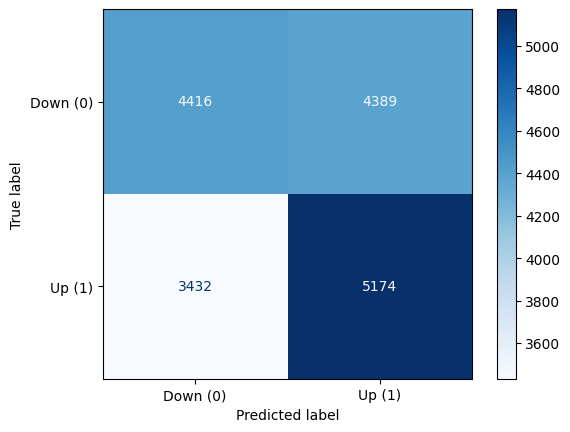

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down (0)", "Up (1)"])
disp.plot(cmap="Blues")


   OUT-OF-SAMPLE PERFORMANCE (TEST SET)
  Trades           : 3,063
  Position Size    : 2% per trade
  Initial Capital  : $1,000.00
  Final Equity     : $1,105.25
  Total Return     : 10.52%
  Win Rate         : 54.91%
  Avg Win/Trade    : 1.4814%
  Avg Loss/Trade   : -1.4414%
  Profit Factor    : 1.252
  Sharpe Ratio     : 18.719
  Max Drawdown     : -1.18%


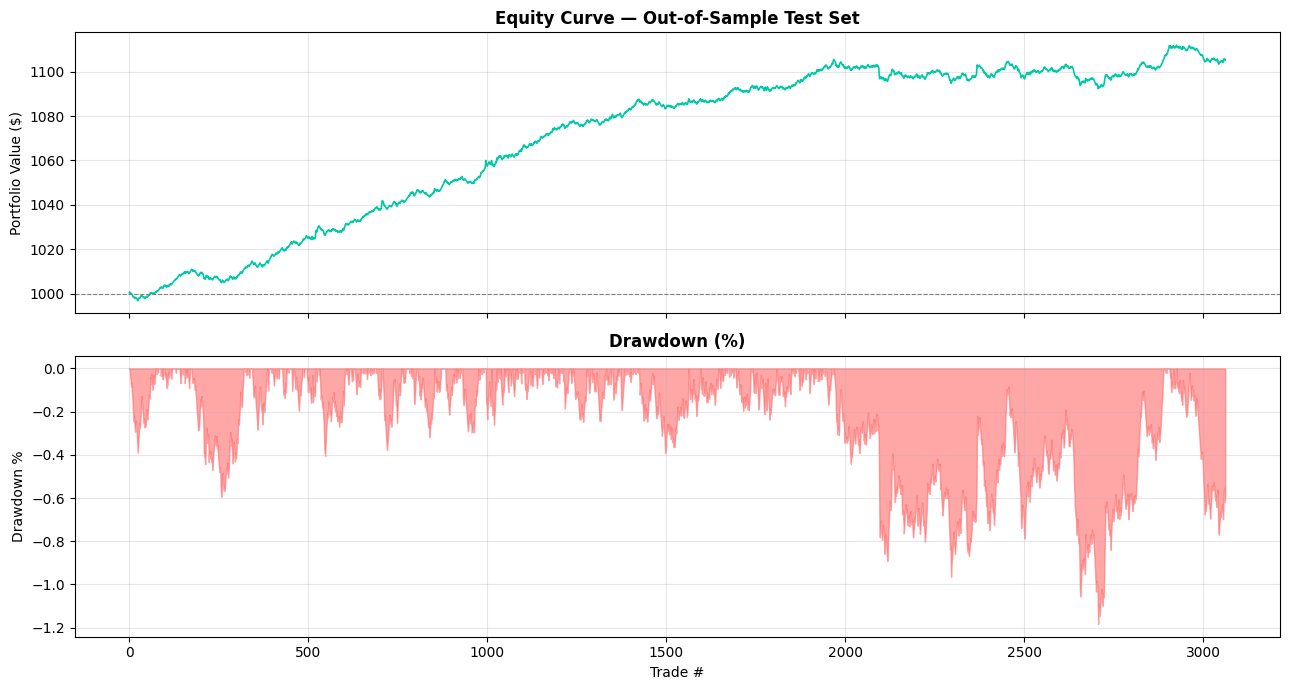

In [ ]:
INITIAL_CAPITAL = 1000
POSITION_SIZE   = 0.02   # risk 2% of capital per trade (realistic)

# ── Use ONLY test data (model never saw this) ──────────────────────────
test_copy = test_df.dropna(subset=feature_cols + ["target"]).copy()
X_eval    = test_copy[feature_cols]
y_eval    = test_copy["target"]

y_pred_test  = model.predict(X_eval)
y_proba_test = model.predict_proba(X_eval)[:, 1]

# ── Build trade results ────────────────────────────────────────────────
trades = pd.DataFrame({
    "y_true"        : y_eval.values,
    "y_pred"        : y_pred_test,
    "y_proba"       : y_proba_test,
    "actual_return" : test_copy["target_simple_return"].values
})

# Long if pred=1, Short if pred=0
trades["trade_return"] = np.where(
    trades["y_pred"] == 1,
     trades["actual_return"],
    -trades["actual_return"]
)

# Fixed position size: only risk POSITION_SIZE % of equity per trade
trades["pnl_pct"]  = trades["trade_return"] * POSITION_SIZE
trades["equity"]   = INITIAL_CAPITAL * (1 + trades["pnl_pct"]).cumprod()

# ── Metrics ────────────────────────────────────────────────────────────
final_equity = trades["equity"].iloc[-1]
total_return = (final_equity / INITIAL_CAPITAL - 1) * 100
win_rate     = (trades["trade_return"] > 0).mean() * 100
avg_win      = trades.loc[trades["trade_return"] > 0, "trade_return"].mean() * 100
avg_loss     = trades.loc[trades["trade_return"] < 0, "trade_return"].mean() * 100
peak         = trades["equity"].cummax()
drawdown     = (trades["equity"] - peak) / peak
max_dd       = drawdown.min() * 100
n_trades     = len(trades)

# Sharpe (15-min → 35040 periods/year)
r            = trades["pnl_pct"]
sharpe       = (r.mean() / r.std()) * np.sqrt(35_040)

# Profit Factor
gross_profit = trades.loc[trades["trade_return"] > 0, "trade_return"].sum()
gross_loss   = trades.loc[trades["trade_return"] < 0, "trade_return"].abs().sum()
pf           = gross_profit / gross_loss if gross_loss else np.inf

print("=" * 42)
print("   OUT-OF-SAMPLE PERFORMANCE (TEST SET)")
print("=" * 42)
print(f"  Trades           : {n_trades:,}")
print(f"  Position Size    : {POSITION_SIZE*100:.0f}% per trade")
print(f"  Initial Capital  : ${INITIAL_CAPITAL:,.2f}")
print(f"  Final Equity     : ${final_equity:,.2f}")
print(f"  Total Return     : {total_return:.2f}%")
print(f"  Win Rate         : {win_rate:.2f}%")
print(f"  Avg Win/Trade    : {avg_win:.4f}%")
print(f"  Avg Loss/Trade   : {avg_loss:.4f}%")
print(f"  Profit Factor    : {pf:.3f}")
print(f"  Sharpe Ratio     : {sharpe:.3f}")
print(f"  Max Drawdown     : {max_dd:.2f}%")
print("=" * 42)

# ── Plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(trades["equity"].values, color="#00C9A7", linewidth=1.2)
axes[0].axhline(INITIAL_CAPITAL, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("Equity Curve — Out-of-Sample Test Set", fontweight="bold")
axes[0].set_ylabel("Portfolio Value ($)")
axes[0].grid(alpha=0.3)

axes[1].fill_between(range(n_trades), drawdown.values * 100, 0, color="#FF6B6B", alpha=0.6)
axes[1].set_title("Drawdown (%)", fontweight="bold")
axes[1].set_ylabel("Drawdown %")
axes[1].set_xlabel("Trade #")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



── LGBM Classification Report ──
              precision    recall  f1-score   support

    Down (0)       0.60      0.57      0.58      1623
      Up (1)       0.54      0.56      0.55      1440

    accuracy                           0.57      3063
   macro avg       0.57      0.57      0.57      3063
weighted avg       0.57      0.57      0.57      3063


  Logistic Regression (Benchmark) — Test Set
  Final Equity   : $1,105.25
  Total Return   : 10.52%
  Win Rate       : 54.91%
  Avg Win        : 1.4814%
  Avg Loss       : -1.4414%
  Profit Factor  : 1.252
  Max Drawdown   : -1.18%

  LGBMClassifier — Test Set
  Final Equity   : $1,152.17
  Total Return   : 15.22%
  Win Rate       : 56.90%
  Avg Win        : 1.4892%
  Avg Loss       : -1.4292%
  Profit Factor  : 1.376
  Max Drawdown   : -1.00%


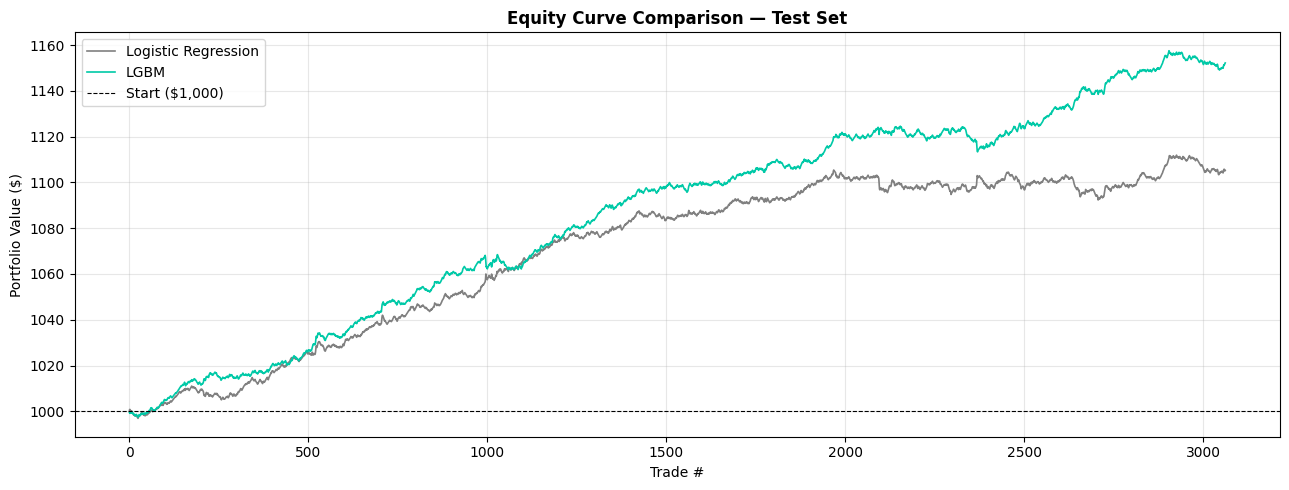

In [45]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# ── Train LGBM ─────────────────────────────────────────────────────────
lgbm_model = LGBMClassifier(
    max_depth=2,
    num_leaves=7,
    min_child_samples=100,
    n_estimators=150,
    learning_rate=0.03,
    reg_alpha=1.5,
    reg_lambda=1.5,
    subsample=0.6,
    colsample_bytree=0.6,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)

# ── Predict on test set ────────────────────────────────────────────────
y_pred_lgbm  = lgbm_model.predict(X_eval)
y_proba_lgbm = lgbm_model.predict_proba(X_eval)[:, 1]

# ── Classification Report ──────────────────────────────────────────────
print("── LGBM Classification Report ──")
print(classification_report(y_eval, y_pred_lgbm, target_names=["Down (0)", "Up (1)"]))

# ── Trading Metrics Function ───────────────────────────────────────────
def trading_metrics(y_true, y_pred, y_proba, actual_returns,
                    capital=1000, pos_size=0.02, label="Model"):
    trades = pd.DataFrame({
        "y_true"        : y_true,
        "y_pred"        : y_pred,
        "y_proba"       : y_proba,
        "actual_return" : actual_returns
    })
    trades["trade_return"] = np.where(trades["y_pred"] == 1,
                                       trades["actual_return"],
                                      -trades["actual_return"])
    trades["pnl_pct"] = trades["trade_return"] * pos_size
    trades["equity"]  = capital * (1 + trades["pnl_pct"]).cumprod()

    final_eq  = trades["equity"].iloc[-1]
    total_ret = (final_eq / capital - 1) * 100
    win_rate  = (trades["trade_return"] > 0).mean() * 100
    avg_win   = trades.loc[trades["trade_return"] > 0, "trade_return"].mean() * 100
    avg_loss  = trades.loc[trades["trade_return"] < 0, "trade_return"].mean() * 100
    peak      = trades["equity"].cummax()
    dd        = (trades["equity"] - peak) / peak
    max_dd    = dd.min() * 100
    gp        = trades.loc[trades["trade_return"] > 0, "trade_return"].sum()
    gl        = trades.loc[trades["trade_return"] < 0, "trade_return"].abs().sum()
    pf        = gp / gl if gl else np.inf

    print(f"\n{'='*42}")
    print(f"  {label} — Test Set")
    print(f"{'='*42}")
    print(f"  Final Equity   : ${final_eq:,.2f}")
    print(f"  Total Return   : {total_ret:.2f}%")
    print(f"  Win Rate       : {win_rate:.2f}%")
    print(f"  Avg Win        : {avg_win:.4f}%")
    print(f"  Avg Loss       : {avg_loss:.4f}%")
    print(f"  Profit Factor  : {pf:.3f}")
    print(f"  Max Drawdown   : {max_dd:.2f}%")
    print(f"{'='*42}")

    return trades

# ── Run both models ────────────────────────────────────────────────────
actual_ret = test_copy["target_simple_return"].values

trades_lr   = trading_metrics(y_eval.values, y_pred_test,  y_proba_test,
                               actual_ret, label="Logistic Regression (Benchmark)")
trades_lgbm = trading_metrics(y_eval.values, y_pred_lgbm, y_proba_lgbm,
                               actual_ret, label="LGBMClassifier")

# ── Plot both equity curves ────────────────────────────────────────────
plt.figure(figsize=(13, 5))
plt.plot(trades_lr["equity"].values,   color="gray",     linewidth=1.2, label="Logistic Regression")
plt.plot(trades_lgbm["equity"].values, color="#00C9A7",  linewidth=1.2, label="LGBM")
plt.axhline(1000, color="black", linestyle="--", linewidth=0.8, label="Start ($1,000)")
plt.title("Equity Curve Comparison — Test Set", fontweight="bold")
plt.ylabel("Portfolio Value ($)")
plt.xlabel("Trade #")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [46]:
print(trades_lgbm[["trade_return", "equity"]].describe())

final_eq  = trades_lgbm["equity"].iloc[-1]
total_ret = (final_eq / 1000 - 1) * 100
win_rate  = (trades_lgbm["trade_return"] > 0).mean() * 100
print(f"\nFinal Equity  : ${final_eq:,.2f}")
print(f"Total Return  : {total_ret:.2f}%")
print(f"Win Rate      : {win_rate:.2f}%")


       trade_return       equity
count   3063.000000  3063.000000
mean       0.002315  1086.284575
std        0.016280    45.478982
min       -0.111366   997.428039
25%       -0.011426  1048.101943
50%        0.009722  1098.204087
75%        0.013257  1121.677601
max        0.108122  1157.515368

Final Equity  : $1,152.17
Total Return  : 15.22%
Win Rate      : 56.90%
